# Section 8 — Predictive Modelling

In this section, we use historical insurance data to build a predictive
model for aggregate annual ultimate claim costs.

The objective is to investigate whether historical claims, claim numbers,
premium and policy information can help explain and predict future
aggregate claim costs.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [42]:
claims = pd.read_csv(
    "../data/raw/ncid_private_motor_ultimate_claims.csv"
)

premium = pd.read_csv(
    "../data/raw/ncid_private_motor_ultimate_prem_claims.csv"
)

print("Claims shape:", claims.shape)
print("Premium shape:", premium.shape)

Claims shape: (840, 5)
Premium shape: (240, 6)


In [43]:
claim_costs = claims[
    claims["Measure"] == "Ultimate Costs"
].copy()

claim_numbers = claims[
    claims["Measure"] == "Ultimate Numbers (incl. nils)"
].copy()

earned_premium = premium[
    premium["Measure"] == "Gross Earned Premium"
].copy()

policy_count = premium[
    premium["Measure"] == "Earned Policy Count"
].copy()

In [44]:
annual_claims = (
    claim_costs
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Ultimate_Claims")
)

annual_claim_numbers = (
    claim_numbers
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Ultimate_Claim_Numbers")
)

annual_premium = (
    earned_premium
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Gross_Earned_Premium")
)

annual_policies = (
    policy_count
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Earned_Policy_Count")
)

In [45]:
annual_claims = (
    claim_costs
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Ultimate_Claims")
)

annual_claim_numbers = (
    claim_numbers
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Ultimate_Claim_Numbers")
)

annual_premium = (
    earned_premium
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Gross_Earned_Premium")
)

annual_policies = (
    policy_count
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Earned_Policy_Count")
)

In [46]:
model_data = annual_claims.merge(
    annual_claim_numbers,
    on="Year",
    how="inner"
)

model_data = model_data.merge(
    annual_premium,
    on="Year",
    how="inner"
)

model_data = model_data.merge(
    annual_policies,
    on="Year",
    how="inner"
)

model_data

,Year,Ultimate_Claims,Ultimate_Claim_Numbers,Gross_Earned_Premium,Earned_Policy_Count
0,2010,1.021937e+09,267542.999992,8.837430e+08,1.750216e+06
1,2011,1.120315e+09,241163.999998,8.818788e+08,1.802330e+06
2,2012,1.167094e+09,235807.999993,8.516703e+08,1.869111e+06
3,2013,1.179432e+09,235162.216532,8.090500e+08,1.873237e+06
4,2014,1.289716e+09,232566.492670,8.236361e+08,1.856551e+06
5,2015,1.210674e+09,211517.024917,8.934833e+08,1.813256e+06
6,2016,1.178402e+09,192841.441877,1.075443e+09,1.793367e+06
7,2017,1.168518e+09,181304.293792,1.284577e+09,1.863651e+06
8,2018,1.119118e+09,186561.641742,1.324302e+09,1.878687e+06
9,2019,1.058611e+09,182102.052885,1.307507e+09,1.948466e+06


In [47]:
model_data["Claim_Frequency"] = (
    model_data["Ultimate_Claim_Numbers"]
    / model_data["Earned_Policy_Count"]
)

In [48]:
model_data["Average_Claim_Cost"] = (
    model_data["Ultimate_Claims"]
    / model_data["Ultimate_Claim_Numbers"]
)

In [49]:
model_data["Loss_Ratio"] = (
    model_data["Ultimate_Claims"]
    / model_data["Gross_Earned_Premium"]
)

In [50]:
model_data

,Year,Ultimate_Claims,Ultimate_Claim_Numbers,Gross_Earned_Premium,Earned_Policy_Count,Claim_Frequency,Average_Claim_Cost,Loss_Ratio
0,2010,1.021937e+09,267542.999992,8.837430e+08,1.750216e+06,0.152863,3819.711560,1.156374
1,2011,1.120315e+09,241163.999998,8.818788e+08,1.802330e+06,0.133807,4645.448738,1.270373
2,2012,1.167094e+09,235807.999993,8.516703e+08,1.869111e+06,0.126161,4949.341053,1.370359
3,2013,1.179432e+09,235162.216532,8.090500e+08,1.873237e+06,0.125538,5015.399314,1.457799
4,2014,1.289716e+09,232566.492670,8.236361e+08,1.856551e+06,0.125268,5545.578472,1.565881
5,2015,1.210674e+09,211517.024917,8.934833e+08,1.813256e+06,0.116650,5723.766697,1.355005
6,2016,1.178402e+09,192841.441877,1.075443e+09,1.793367e+06,0.107530,6110.730942,1.095736
7,2017,1.168518e+09,181304.293792,1.284577e+09,1.863651e+06,0.097284,6445.063909,0.909652
8,2018,1.119118e+09,186561.641742,1.324302e+09,1.878687e+06,0.099304,5998.652663,0.845063
9,2019,1.058611e+09,182102.052885,1.307507e+09,1.948466e+06,0.093459,5813.281644,0.809640


In [51]:
y = model_data["Ultimate_Claims"]

In [52]:
X = model_data[
    [
        "Year",
        "Ultimate_Claim_Numbers",
        "Gross_Earned_Premium",
        "Earned_Policy_Count"
    ]
]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 12
Testing observations: 3


In [54]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ -0.08,4823.12, 0.38, 47.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Year','Ultimate_Claim_Numbers','Gross_Earned_Premium', 'Earned_Policy_Count']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.22e+08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [55]:
y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    "Actual_Claims": y_test.values,
    "Predicted_Claims": y_pred
})

predictions

,Actual_Claims,Predicted_Claims
0,1.058611e+09,1.141620e+09
1,9.584447e+08,1.046878e+09
2,1.021937e+09,1.384596e+09


In [56]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 178033539.1609685


In [57]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -27.469381132707465


In [58]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 220780512.93886817


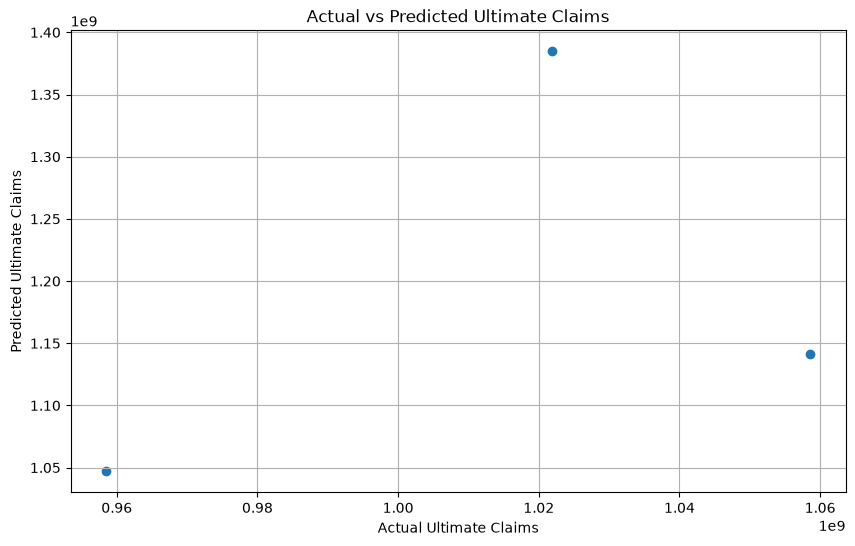

In [59]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Ultimate Claims")
plt.ylabel("Predicted Ultimate Claims")
plt.title("Actual vs Predicted Ultimate Claims")

plt.grid(True)
plt.show()

In [60]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Year,-0.082687
1,Ultimate_Claim_Numbers,4823.122917
2,Gross_Earned_Premium,0.376863
3,Earned_Policy_Count,47.490583


## Section  Summary

A Linear Regression model was developed to predict aggregate annual
ultimate claim costs using historical insurance information.

The model uses annual claim numbers, gross earned premium, earned
policy count and year as explanatory variables.

Model performance was evaluated using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE) and R².

The actual and predicted claim costs were also compared visually.

Because the NCID dataset contains aggregate insurance information,
the model should be interpreted as an aggregate predictive analysis
rather than an individual policyholder risk model.

# Section  Model Improvement & Forecasting

In this section, we improve the predictive modelling approach by
using a time-based train-test split.

Earlier years are used to train the model, while later years are
used to evaluate its ability to predict future aggregate ultimate
claim costs.

In [61]:
model_data = model_data.sort_values("Year").reset_index(drop=True)

model_data

,Year,Ultimate_Claims,Ultimate_Claim_Numbers,Gross_Earned_Premium,Earned_Policy_Count,Claim_Frequency,Average_Claim_Cost,Loss_Ratio
0,2010,1.021937e+09,267542.999992,8.837430e+08,1.750216e+06,0.152863,3819.711560,1.156374
1,2011,1.120315e+09,241163.999998,8.818788e+08,1.802330e+06,0.133807,4645.448738,1.270373
2,2012,1.167094e+09,235807.999993,8.516703e+08,1.869111e+06,0.126161,4949.341053,1.370359
3,2013,1.179432e+09,235162.216532,8.090500e+08,1.873237e+06,0.125538,5015.399314,1.457799
4,2014,1.289716e+09,232566.492670,8.236361e+08,1.856551e+06,0.125268,5545.578472,1.565881
5,2015,1.210674e+09,211517.024917,8.934833e+08,1.813256e+06,0.116650,5723.766697,1.355005
6,2016,1.178402e+09,192841.441877,1.075443e+09,1.793367e+06,0.107530,6110.730942,1.095736
7,2017,1.168518e+09,181304.293792,1.284577e+09,1.863651e+06,0.097284,6445.063909,0.909652
8,2018,1.119118e+09,186561.641742,1.324302e+09,1.878687e+06,0.099304,5998.652663,0.845063
9,2019,1.058611e+09,182102.052885,1.307507e+09,1.948466e+06,0.093459,5813.281644,0.809640


In [62]:
model_data["Previous_Claims"] = (
    model_data["Ultimate_Claims"].shift(1)
)

model_data["Previous_Claim_Numbers"] = (
    model_data["Ultimate_Claim_Numbers"].shift(1)
)

model_data["Previous_Premium"] = (
    model_data["Gross_Earned_Premium"].shift(1)
)

model_data["Previous_Policies"] = (
    model_data["Earned_Policy_Count"].shift(1)
)

In [63]:
model_data = model_data.dropna().reset_index(drop=True)

model_data

,Year,Ultimate_Claims,Ultimate_Claim_Numbers,Gross_Earned_Premium,Earned_Policy_Count,Claim_Frequency,Average_Claim_Cost,Loss_Ratio,Previous_Claims,Previous_Claim_Numbers,Previous_Premium,Previous_Policies
0,2011,1.120315e+09,241163.999998,8.818788e+08,1.802330e+06,0.133807,4645.448738,1.270373,1.021937e+09,267542.999992,8.837430e+08,1.750216e+06
1,2012,1.167094e+09,235807.999993,8.516703e+08,1.869111e+06,0.126161,4949.341053,1.370359,1.120315e+09,241163.999998,8.818788e+08,1.802330e+06
2,2013,1.179432e+09,235162.216532,8.090500e+08,1.873237e+06,0.125538,5015.399314,1.457799,1.167094e+09,235807.999993,8.516703e+08,1.869111e+06
3,2014,1.289716e+09,232566.492670,8.236361e+08,1.856551e+06,0.125268,5545.578472,1.565881,1.179432e+09,235162.216532,8.090500e+08,1.873237e+06
4,2015,1.210674e+09,211517.024917,8.934833e+08,1.813256e+06,0.116650,5723.766697,1.355005,1.289716e+09,232566.492670,8.236361e+08,1.856551e+06
5,2016,1.178402e+09,192841.441877,1.075443e+09,1.793367e+06,0.107530,6110.730942,1.095736,1.210674e+09,211517.024917,8.934833e+08,1.813256e+06
6,2017,1.168518e+09,181304.293792,1.284577e+09,1.863651e+06,0.097284,6445.063909,0.909652,1.178402e+09,192841.441877,1.075443e+09,1.793367e+06
7,2018,1.119118e+09,186561.641742,1.324302e+09,1.878687e+06,0.099304,5998.652663,0.845063,1.168518e+09,181304.293792,1.284577e+09,1.863651e+06
8,2019,1.058611e+09,182102.052885,1.307507e+09,1.948466e+06,0.093459,5813.281644,0.809640,1.119118e+09,186561.641742,1.324302e+09,1.878687e+06
9,2020,8.509247e+08,142765.601173,1.258439e+09,2.043974e+06,0.069847,5960.292475,0.676175,1.058611e+09,182102.052885,1.307507e+09,1.948466e+06


In [64]:
X = model_data[
    [
        "Year",
        "Previous_Claims",
        "Previous_Claim_Numbers",
        "Previous_Premium",
        "Previous_Policies"
    ]
]

y = model_data["Ultimate_Claims"]

In [65]:
split_index = int(len(model_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training years:")
print(model_data.iloc[:split_index]["Year"].tolist())

print("\nTesting years:")
print(model_data.iloc[split_index:]["Year"].tolist())

Training years:
[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

Testing years:
[2022, 2023, 2024]


In [66]:
improved_model = LinearRegression()

improved_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.09, 0.31,-1563.95, -0.49, -494.76]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Year','Previous_Claims','Previous_Claim_Numbers','Previous_Premium', 'Previous_Policies']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.521e+09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [67]:
y_pred = improved_model.predict(X_test)

forecast_results = pd.DataFrame({
    "Year": model_data.iloc[split_index:]["Year"].values,
    "Actual_Claims": y_test.values,
    "Predicted_Claims": y_pred
})

forecast_results

,Year,Actual_Claims,Predicted_Claims
0,2022,1.224618e+09,9.024655e+08
1,2023,1.293268e+09,9.174557e+08
2,2024,1.359448e+09,8.964777e+08


In [68]:
mae_improved = mean_absolute_error(
    y_test,
    y_pred
)

print("Improved Model MAE:", mae_improved)

Improved Model MAE: 386978495.06036836


In [69]:
rmse_improved = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Improved Model RMSE:", rmse_improved)

Improved Model RMSE: 391305086.9171147


In [70]:
r2_improved = r2_score(
    y_test,
    y_pred
)

print("Improved Model R²:", r2_improved)

Improved Model R²: -49.53075104286776


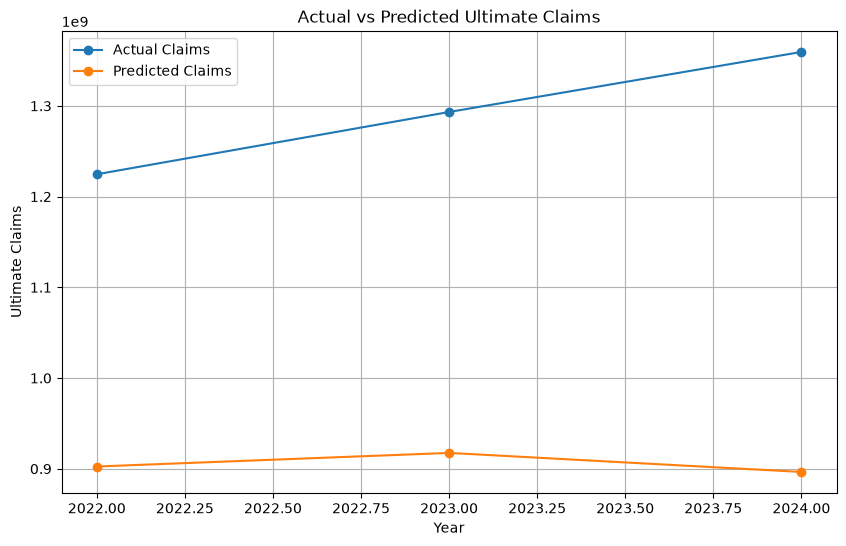

In [71]:
plt.figure(figsize=(10, 6))

plt.plot(
    forecast_results["Year"],
    forecast_results["Actual_Claims"],
    marker="o",
    label="Actual Claims"
)

plt.plot(
    forecast_results["Year"],
    forecast_results["Predicted_Claims"],
    marker="o",
    label="Predicted Claims"
)

plt.title("Actual vs Predicted Ultimate Claims")
plt.xlabel("Year")
plt.ylabel("Ultimate Claims")

plt.legend()
plt.grid(True)

plt.show()

In [72]:
forecast_results["Prediction_Error"] = (
    forecast_results["Actual_Claims"]
    - forecast_results["Predicted_Claims"]
)

forecast_results

,Year,Actual_Claims,Predicted_Claims,Prediction_Error
0,2022,1.224618e+09,9.024655e+08,3.221522e+08
1,2023,1.293268e+09,9.174557e+08,3.758126e+08
2,2024,1.359448e+09,8.964777e+08,4.629707e+08


In [73]:
forecast_results["Percentage_Error"] = (
    forecast_results["Prediction_Error"]
    / forecast_results["Actual_Claims"]
) * 100

forecast_results

,Year,Actual_Claims,Predicted_Claims,Prediction_Error,Percentage_Error
0,2022,1.224618e+09,9.024655e+08,3.221522e+08,26.306346
1,2023,1.293268e+09,9.174557e+08,3.758126e+08,29.059137
2,2024,1.359448e+09,8.964777e+08,4.629707e+08,34.055775


In [74]:
model_comparison = pd.DataFrame({
    "Model": [
        "Basic Linear Regression",
        "Time-Based Linear Regression"
    ],
    "MAE": [
        mae,
        mae_improved
    ],
    "RMSE": [
        rmse,
        rmse_improved
    ],
    "R2": [
        r2,
        r2_improved
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Basic Linear Regression,1.780335e+08,2.207805e+08,-27.469381
1,Time-Based Linear Regression,3.869785e+08,3.913051e+08,-49.530751


## Section  Summary

The predictive modelling approach was improved by introducing a
time-based train-test split.

Historical information from previous years was used to predict
aggregate ultimate claim costs for later years.

The improved model was evaluated using MAE, RMSE and R² and its
predictions were compared with actual ultimate claim costs.

The time-based approach is more appropriate for forecasting than a
random train-test split because insurance data is naturally ordered
through time.

However, the dataset contains a relatively small number of annual
observations, so the forecasting results should be interpreted as
an analytical exercise rather than a production forecasting model.

## Results & Business Recommendations

This section summarises the key findings from the actuarial analysis,
premium and claims analysis, loss ratio analysis and predictive modelling.

The findings are translated into practical business recommendations
for insurance risk management and decision-making.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

claims = pd.read_csv("../data/raw/ncid_private_motor_ultimate_claims.csv")
premium = pd.read_csv("../data/raw/ncid_private_motor_ultimate_prem_claims.csv")

In [76]:
claim_costs = claims[
    claims["Measure"] == "Ultimate Costs"
].copy()

earned_premium = premium[
    premium["Measure"] == "Gross Earned Premium"
].copy()

In [77]:
annual_claims = (
    claim_costs
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Ultimate_Claims")
)

annual_premium = (
    earned_premium
    .groupby("Year")["Value"]
    .sum()
    .reset_index(name="Gross_Earned_Premium")
)

In [78]:
claims_premium = annual_claims.merge(
    annual_premium,
    on="Year",
    how="inner"
)

claims_premium["Loss_Ratio"] = (
    claims_premium["Ultimate_Claims"]
    / claims_premium["Gross_Earned_Premium"]
) * 100

claims_premium

,Year,Ultimate_Claims,Gross_Earned_Premium,Loss_Ratio
0,2010,1.021937e+09,8.837430e+08,115.637360
1,2011,1.120315e+09,8.818788e+08,127.037292
2,2012,1.167094e+09,8.516703e+08,137.035911
3,2013,1.179432e+09,8.090500e+08,145.779922
4,2014,1.289716e+09,8.236361e+08,156.588061
5,2015,1.210674e+09,8.934833e+08,135.500478
6,2016,1.178402e+09,1.075443e+09,109.573648
7,2017,1.168518e+09,1.284577e+09,90.965207
8,2018,1.119118e+09,1.324302e+09,84.506286
9,2019,1.058611e+09,1.307507e+09,80.964019


In [79]:
final_results = claims_premium[
    [
        "Year",
        "Ultimate_Claims",
        "Gross_Earned_Premium",
        "Loss_Ratio"
    ]
].copy()

final_results

,Year,Ultimate_Claims,Gross_Earned_Premium,Loss_Ratio
0,2010,1.021937e+09,8.837430e+08,115.637360
1,2011,1.120315e+09,8.818788e+08,127.037292
2,2012,1.167094e+09,8.516703e+08,137.035911
3,2013,1.179432e+09,8.090500e+08,145.779922
4,2014,1.289716e+09,8.236361e+08,156.588061
5,2015,1.210674e+09,8.934833e+08,135.500478
6,2016,1.178402e+09,1.075443e+09,109.573648
7,2017,1.168518e+09,1.284577e+09,90.965207
8,2018,1.119118e+09,1.324302e+09,84.506286
9,2019,1.058611e+09,1.307507e+09,80.964019


In [80]:
final_results = claims_premium[
    [
        "Year",
        "Ultimate_Claims",
        "Gross_Earned_Premium",
        "Loss_Ratio"
    ]
].copy()

final_results

,Year,Ultimate_Claims,Gross_Earned_Premium,Loss_Ratio
0,2010,1.021937e+09,8.837430e+08,115.637360
1,2011,1.120315e+09,8.818788e+08,127.037292
2,2012,1.167094e+09,8.516703e+08,137.035911
3,2013,1.179432e+09,8.090500e+08,145.779922
4,2014,1.289716e+09,8.236361e+08,156.588061
5,2015,1.210674e+09,8.934833e+08,135.500478
6,2016,1.178402e+09,1.075443e+09,109.573648
7,2017,1.168518e+09,1.284577e+09,90.965207
8,2018,1.119118e+09,1.324302e+09,84.506286
9,2019,1.058611e+09,1.307507e+09,80.964019


In [81]:
highest_loss_year = claims_premium.loc[
    claims_premium["Loss_Ratio"].idxmax()
]

print("Year with highest loss ratio:",
      highest_loss_year["Year"])

print("Highest loss ratio:",
      round(highest_loss_year["Loss_Ratio"], 2), "%")

Year with highest loss ratio: 2014.0
Highest loss ratio: 156.59 %


In [82]:
lowest_loss_year = claims_premium.loc[
    claims_premium["Loss_Ratio"].idxmin()
]

print("Year with lowest loss ratio:",
      lowest_loss_year["Year"])

print("Lowest loss ratio:",
      round(lowest_loss_year["Loss_Ratio"], 2), "%")

Year with lowest loss ratio: 2020.0
Lowest loss ratio: 67.62 %


In [85]:
claims_by_type = (
    claim_costs
    .groupby("ClaimType")["Value"]
    .sum()
    .sort_values(ascending=False)
)

In [86]:
highest_claim_type = claims_by_type.idxmax()
highest_claim_value = claims_by_type.max()

print("Highest-cost claim type:",
      highest_claim_type)

print("Ultimate claim cost:",
      highest_claim_value)

Highest-cost claim type: Third Party Injury (Total)
Ultimate claim cost: 6812705164.150397


In [87]:
premium_by_cover = (
    earned_premium
    .groupby("CoverType")["Value"]
    .sum()
    .sort_values(ascending=False)
)

In [88]:
highest_premium_cover = premium_by_cover.idxmax()
highest_premium_value = premium_by_cover.max()

print("Cover type with highest premium:",
      highest_premium_cover)

print("Gross earned premium:",
      highest_premium_value)

Cover type with highest premium: Comprehensive
Gross earned premium: 13656553673.933878


In [89]:
print("Time-Based Model Results")
print("------------------------")
print("MAE:", round(mae_improved, 2))
print("RMSE:", round(rmse_improved, 2))
print("R²:", round(r2_improved, 4))

Time-Based Model Results
------------------------
MAE: 386978495.06
RMSE: 391305086.92
R²: -49.5308


## Business Recommendations

### 1. Monitor Loss Ratios

Insurers should regularly monitor loss ratios because increases may
indicate growing claims pressure relative to premium.

### 2. Focus on High-Cost Claim Types

Claim categories that contribute a large proportion of ultimate claim
costs should receive additional attention during claims management,
reserving and risk assessment.

### 3. Use Historical Trends for Planning

Historical claims, premium and policy trends can support actuarial
planning, budgeting and forecasting.

### 4. Improve Predictive Modelling

Predictive models can be developed further with more detailed data,
additional variables and larger datasets to improve forecasting
accuracy.

### 5. Support Actuarial Decision-Making

The analysis can support decisions relating to insurance risk,
pricing analysis, claims management and financial planning.

## Project Limitations

### 1. Aggregate Data

The NCID dataset contains aggregate insurance information rather than
individual policyholder-level data. Therefore, the model does not
predict the probability of a claim for an individual driver.

### 2. Limited Number of Annual Observations

The analysis covers a limited number of annual observations. This
restricts the complexity and reliability of predictive modelling.

### 3. Limited Predictors

The available dataset does not contain detailed driver, vehicle,
location or policy-level risk characteristics.

### 4. Forecasting Limitations

The forecasting model is an analytical exercise and should not be
considered a production-level insurance forecasting model.

### 5. Loss Ratio Is Not Profit

The loss ratio measures claims relative to earned premium. It does not
represent overall insurer profitability because other expenses and
financial factors are not included.

## Key Findings

The analysis provided several insights into Irish private motor
insurance claims and premiums.

- Ultimate claim costs and gross earned premiums were analysed over
  time to identify historical trends.

- Claim frequency and average ultimate claim cost were calculated to
  provide actuarial measures of insurance risk.

- Loss ratio analysis showed how ultimate claims compared with gross
  earned premium across different years.

- Claim-type analysis identified the categories contributing most to
  ultimate claim costs.

- Predictive modelling demonstrated how historical insurance
  information can be used to estimate aggregate future claim costs.

- A time-based modelling approach was used to make the forecasting
  methodology more appropriate for yearly insurance data.

Overall, the project demonstrates how actuarial analysis, exploratory
data analysis and predictive modelling can be combined to support
insurance risk assessment and business decision-making.

## Overall Conclusion

This project analysed Irish private motor insurance data using
actuarial data analytics and predictive modelling techniques.

The analysis examined ultimate claim costs, ultimate claim numbers,
gross earned premium and earned policy counts over time.

Key actuarial measures including claim frequency, average ultimate
claim cost and loss ratio were calculated to assess historical
insurance risk and claims performance.

The analysis also examined claim types and cover types to understand
the main sources of claim costs and premium.

Predictive modelling was then used to investigate whether historical
insurance information could be used to estimate aggregate ultimate
claim costs. A time-based modelling approach was introduced to make
the forecasting process more appropriate for annual insurance data.

Overall, the project demonstrates how insurance data can be analysed
using actuarial techniques, exploratory data analysis and predictive
modelling to support risk assessment, forecasting and business
decision-making.

## Actuarial Insights

The analysis demonstrates the importance of combining several
actuarial measures rather than relying on a single metric.

Claim frequency provides an indication of how often claims occur
relative to the earned policy base.

Average ultimate claim cost provides an indication of the financial
severity of claims.

Loss ratio compares ultimate claim costs with gross earned premium
and provides an important measure of claims pressure relative to
premium.

Together, these measures provide a broader view of insurance risk
and historical claims performance.

## Business Recommendations

Based on the analysis, insurers could:

1. Monitor claim frequency and claim severity regularly to identify
   changes in underlying insurance risk.

2. Monitor loss ratios to identify periods where claims are increasing
   relative to earned premium.

3. Focus claims management and risk analysis on claim categories that
   contribute significantly to ultimate claim costs.

4. Use historical claims and premium trends to support actuarial
   forecasting, budgeting and financial planning.

5. Develop more advanced predictive models when larger and more
   detailed datasets become available.

6. Combine predictive modelling with actuarial judgement rather than
   relying on model outputs alone.

## Limitations

This project has several limitations.

- The dataset contains aggregate insurance information rather than
  individual policyholder-level information.

- The number of annual observations is relatively small for complex
  predictive modelling.

- Detailed risk factors such as driver characteristics, vehicle
  characteristics, geographic information and individual policy
  details are not available.

- The predictive model should therefore be considered an analytical
  forecasting exercise rather than a production insurance pricing
  model.

- Loss ratio does not represent overall profitability because other
  expenses and financial factors are not included.

- The results should be interpreted together with actuarial judgement
  and additional business information.

## Future Improvements

The project could be extended by:

- Using a larger historical dataset.

- Including additional economic variables such as inflation and
  interest rates.

- Including detailed policy and vehicle characteristics where
  available.

- Testing additional machine learning models such as Random Forest,
  Gradient Boosting and XGBoost.

- Using dedicated time-series forecasting techniques.

- Applying cross-validation designed specifically for time-series
  data.

- Developing separate models for claim frequency and claim severity.

- Performing more detailed model validation and sensitivity analysis.

- Comparing model predictions with actuarial assumptions and
  professional judgement.

# Final Project Statement

The project demonstrates an end-to-end actuarial data analytics
workflow, from understanding and preparing insurance data through
exploratory analysis, actuarial calculations, risk analysis and
predictive modelling.

The combination of actuarial measures and data analytics provides a
structured approach to understanding historical insurance claims and
premium performance.

The project also demonstrates the potential of predictive modelling
to support aggregate insurance forecasting while recognising the
importance of data quality, model limitations and actuarial judgement.